# Amazon Fine Food Reviews — Data Preprocessing & ML Training
## Mini-Projet Big Data IASD 2025-2026

**Pipeline:**
1. Load & explore dataset
2. Data cleaning & preprocessing
3. Feature engineering (TF-IDF)
4. Train/Val/Test split (80/10/10)
5. Train multiple ML models
6. Hyperparameter tuning
7. Evaluate & select best model
8. Save best model

## 0. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import re
import pickle
import joblib
import warnings
import os
import json
from pathlib import Path

warnings.filterwarnings('ignore')

# NLTK
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('punkt_tab', quiet=True)

# Scikit-learn
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
from sklearn.pipeline import Pipeline

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Setup
Path('model').mkdir(exist_ok=True)
Path('logs').mkdir(exist_ok=True)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('✅ All imports successful!')
print(f'Working directory: {os.getcwd()}')

✅ All imports successful!
Working directory: /content


## 1. Load Dataset

In [2]:
from google.colab import files
files.upload()  # upload kaggle.json

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"elboumashouliachraf","key":"d1edf2d10b564325335de99443370c0a"}'}

In [3]:
!mkdir -p ~/.config/kaggle
!cp kaggle.json ~/.config/kaggle/
!chmod 600 ~/.config/kaggle/kaggle.json

In [4]:
from kaggle.api.kaggle_api_extended import KaggleApi

api = KaggleApi()
api.authenticate()
api.dataset_download_files(
    'snap/amazon-fine-food-reviews',
    path='/content/Mini-Projet',
    unzip=True
)
print('✅ Dataset downloaded')

Dataset URL: https://www.kaggle.com/datasets/snap/amazon-fine-food-reviews
✅ Dataset downloaded


In [6]:
ls /content/Mini-Projet/Reviews.csv

database.sqlite  hashes.txt  Reviews.csv


In [7]:
# Load dataset
# Download from: https://www.kaggle.com/snap/amazon-fine-food-reviews
CSV_PATH = '/content/Mini-Projet/Reviews.csv'

print(f'Loading dataset from {CSV_PATH}...')
df = pd.read_csv(CSV_PATH)

print(f'\nDataset shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head(3)

Loading dataset from /content/Mini-Projet/Reviews.csv...

Dataset shape: (568454, 10)
Columns: ['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator', 'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text']


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...


In [8]:
# Basic exploration
print('=== Dataset Info ===')
print(df.info())
print('\n=== Missing Values ===')
print(df.isnull().sum())
print('\n=== Score Distribution ===')
print(df['Score'].value_counts().sort_index())

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 568454 entries, 0 to 568453
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   Id                      568454 non-null  int64 
 1   ProductId               568454 non-null  object
 2   UserId                  568454 non-null  object
 3   ProfileName             568428 non-null  object
 4   HelpfulnessNumerator    568454 non-null  int64 
 5   HelpfulnessDenominator  568454 non-null  int64 
 6   Score                   568454 non-null  int64 
 7   Time                    568454 non-null  int64 
 8   Summary                 568427 non-null  object
 9   Text                    568454 non-null  object
dtypes: int64(5), object(5)
memory usage: 43.4+ MB
None

=== Missing Values ===
Id                         0
ProductId                  0
UserId                     0
ProfileName               26
HelpfulnessNumerator       0
Helpful

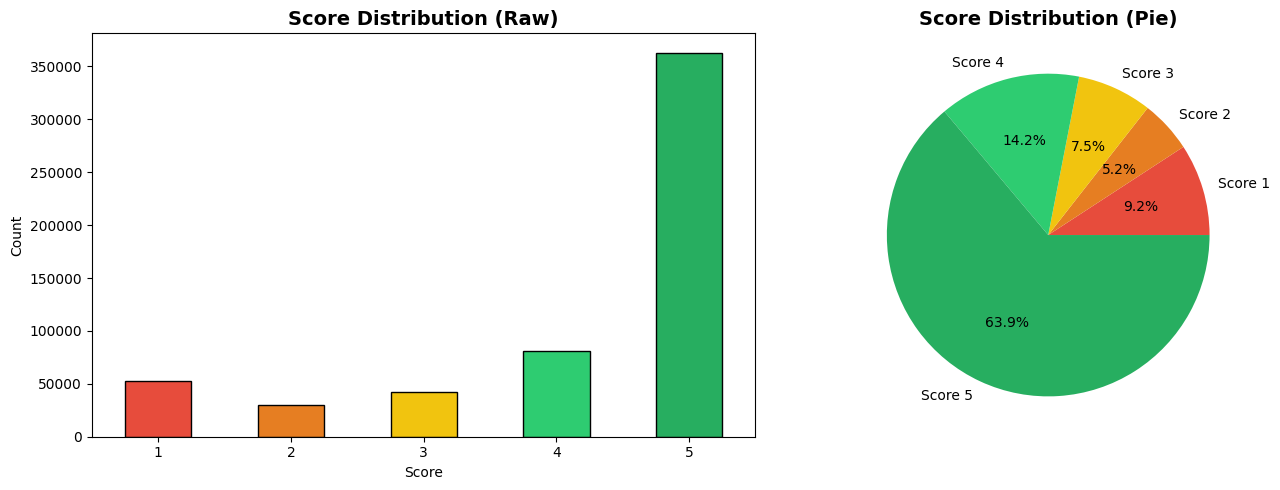

✅ Plot saved to logs/score_distribution.png


In [9]:
# Score distribution plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['Score'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color=['#E74C3C','#E67E22','#F1C40F','#2ECC71','#27AE60'],
    edgecolor='black'
)
axes[0].set_title('Score Distribution (Raw)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Score')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# Pie chart
score_counts = df['Score'].value_counts().sort_index()
axes[1].pie(score_counts, labels=[f'Score {i}' for i in score_counts.index],
            autopct='%1.1f%%', colors=['#E74C3C','#E67E22','#F1C40F','#2ECC71','#27AE60'])
axes[1].set_title('Score Distribution (Pie)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('logs/score_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Plot saved to logs/score_distribution.png')

## 2. Data Cleaning & Label Creation

In [10]:
# --- Label creation ---
# score < 3  => negative (0)
# score == 3 => neutral  (1)
# score > 3  => positive (2)

def create_label(score: int) -> str:
    if score < 3:
        return 'negative'
    elif score == 3:
        return 'neutral'
    else:
        return 'positive'

df['sentiment'] = df['Score'].apply(create_label)

print('=== Sentiment Distribution ===')
print(df['sentiment'].value_counts())
print(f'\nPositive: {(df["sentiment"]=="positive").sum()/len(df)*100:.1f}%')
print(f'Neutral:  {(df["sentiment"]=="neutral").sum()/len(df)*100:.1f}%')
print(f'Negative: {(df["sentiment"]=="negative").sum()/len(df)*100:.1f}%')

=== Sentiment Distribution ===
sentiment
positive    443777
negative     82037
neutral      42640
Name: count, dtype: int64

Positive: 78.1%
Neutral:  7.5%
Negative: 14.4%


In [11]:
# --- Handle missing values ---
print(f'Before cleaning: {len(df)} rows')

# Drop rows where Text or Summary is null (critical columns)
df.dropna(subset=['Text', 'Summary'], inplace=True)

# Drop duplicate reviews (same UserId + Text)
df.drop_duplicates(subset=['UserId', 'Text'], inplace=True)

# Reset index
df.reset_index(drop=True, inplace=True)

print(f'After cleaning: {len(df)} rows')
print(f'Removed: {568454 - len(df)} rows')

Before cleaning: 568454 rows
After cleaning: 393603 rows
Removed: 174851 rows


## 3. Text Preprocessing

In [12]:
# Initialize NLTK tools
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()


def preprocess_text(text: str) -> str:
    """
    Full NLP preprocessing pipeline:
    1. Lowercase
    2. Remove HTML tags
    3. Remove URLs
    4. Remove punctuation & special characters
    5. Tokenize
    6. Remove stopwords
    7. Lemmatize
    """
    if not isinstance(text, str):
        return ''

    # 1. Lowercase
    text = text.lower()

    # 2. Remove HTML tags
    text = re.sub(r'<[^>]+>', ' ', text)

    # 3. Remove URLs
    text = re.sub(r'http\S+|www\S+', ' ', text)

    # 4. Remove punctuation, digits, special characters
    text = re.sub(r'[^a-z\s]', ' ', text)

    # 5. Tokenize
    tokens = word_tokenize(text)

    # 6. Remove stopwords & short tokens
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]

    # 7. Lemmatize
    tokens = [lemmatizer.lemmatize(t) for t in tokens]

    return ' '.join(tokens)


# Test preprocessing
sample = df['Text'].iloc[0]
print('=== Preprocessing Test ===')
print(f'Original ({len(sample)} chars):')
print(sample[:200])
print(f'\nProcessed ({len(preprocess_text(sample))} chars):')
print(preprocess_text(sample)[:200])

=== Preprocessing Test ===
Original (263 chars):
I have bought several of the Vitality canned dog food products and have found them all to be of good quality. The product looks more like a stew than a processed meat and it smells better. My Labrador

Processed (161 chars):
bought several vitality canned dog food product found good quality product look like stew processed meat smell better labrador finicky appreciates product better


In [13]:
# Apply preprocessing to the full dataset
# Combine Summary + Text for richer features
print('Preprocessing text (this may take a few minutes)...')

df['combined_text'] = df['Summary'].fillna('') + ' ' + df['Text'].fillna('')
df['clean_text'] = df['combined_text'].apply(preprocess_text)

# Remove empty texts after cleaning
df = df[df['clean_text'].str.strip() != '']
df.reset_index(drop=True, inplace=True)

print(f'✅ Preprocessing complete. Dataset size: {len(df)}')
print('\nSample clean texts:')
for i in range(3):
    print(f'  [{df["sentiment"].iloc[i]}] {df["clean_text"].iloc[i][:100]}')

Preprocessing text (this may take a few minutes)...
✅ Preprocessing complete. Dataset size: 393601

Sample clean texts:
  [positive] good quality dog food bought several vitality canned dog food product found good quality product loo
  [negative] advertised product arrived labeled jumbo salted peanut peanut actually small sized unsalted sure err
  [positive] delight say confection around century light pillowy citrus gelatin nut case filbert cut tiny square 


## 4. WordCloud Visualization

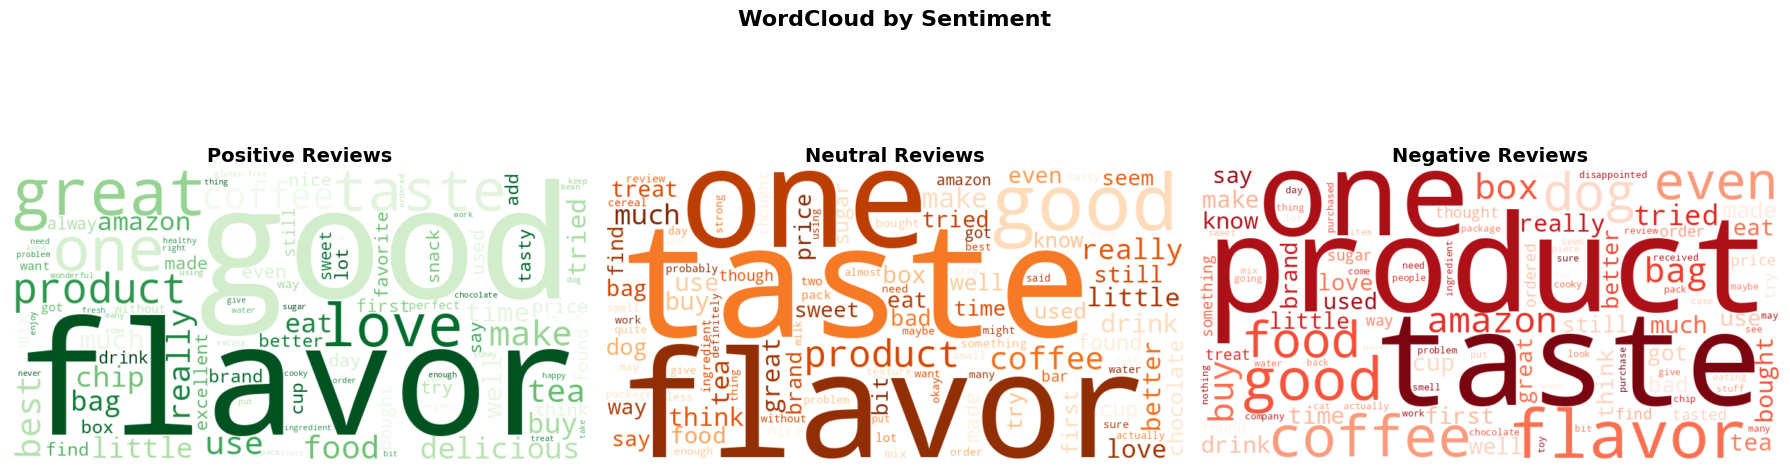

✅ WordCloud saved


In [14]:
# WordCloud for each sentiment
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
sentiments = ['positive', 'neutral', 'negative']
colors = ['Greens', 'Oranges', 'Reds']

for ax, sentiment, colormap in zip(axes, sentiments, colors):
    text_corpus = ' '.join(df[df['sentiment'] == sentiment]['clean_text'].head(5000))
    wc = WordCloud(
        width=800, height=400,
        background_color='white',
        colormap=colormap,
        max_words=100
    ).generate(text_corpus)

    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f'{sentiment.capitalize()} Reviews', fontsize=14, fontweight='bold')

plt.suptitle('WordCloud by Sentiment', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('logs/wordcloud.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ WordCloud saved')

## 5. Feature Engineering & Train/Val/Test Split

In [15]:
# --- Label Encoding ---
le = LabelEncoder()
df['label'] = le.fit_transform(df['sentiment'])

print('Label encoding:')
for i, cls in enumerate(le.classes_):
    print(f'  {cls} => {i}')

# Save label encoder
joblib.dump(le, 'model/label_encoder.pkl')
print('\n✅ Label encoder saved to model/label_encoder.pkl')

Label encoding:
  negative => 0
  neutral => 1
  positive => 2

✅ Label encoder saved to model/label_encoder.pkl


In [17]:
# --- Train / Validation / Test Split: 80 / 10 / 10 ---
X = df['clean_text']
y = df['label']

# First split: 80% train, 20% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

# Second split: 50% of temp = 10% val, 10% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE, stratify=y_temp
)

print('=== Dataset Splits ===')
print(f'Train:      {len(X_train):>7,} samples ({len(X_train)/len(X)*100:.1f}%)')
print(f'Validation: {len(X_val):>7,} samples ({len(X_val)/len(X)*100:.1f}%)')
print(f'Test:       {len(X_test):>7,} samples ({len(X_test)/len(X)*100:.1f}%)')
print(f'Total:      {len(X):>7,} samples')

# Save test set for streaming simulation
test_df = df.loc[X_test.index].copy()
test_df.to_csv('/content/Mini-Projet/test_reviews.csv', index=False)
print('\n✅ Test set saved to /content/Mini-Projet/test_reviews.csv (used for streaming simulation)')

=== Dataset Splits ===
Train:      314,880 samples (80.0%)
Validation:  39,360 samples (10.0%)
Test:        39,361 samples (10.0%)
Total:      393,601 samples

✅ Test set saved to /content/Mini-Projet/test_reviews.csv (used for streaming simulation)


In [18]:
# --- TF-IDF Vectorization ---
print('Fitting TF-IDF vectorizer on training data...')

tfidf = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2),      # unigrams + bigrams
    min_df=2,                # ignore very rare terms
    max_df=0.95,             # ignore very common terms
    sublinear_tf=True        # apply log normalization
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf   = tfidf.transform(X_val)
X_test_tfidf  = tfidf.transform(X_test)

print(f'✅ TF-IDF fitted')
print(f'   Vocabulary size: {len(tfidf.vocabulary_):,}')
print(f'   Train matrix:    {X_train_tfidf.shape}')
print(f'   Val matrix:      {X_val_tfidf.shape}')
print(f'   Test matrix:     {X_test_tfidf.shape}')

# Save vectorizer
joblib.dump(tfidf, 'model/tfidf_vectorizer.pkl')
print('\n✅ TF-IDF vectorizer saved to model/tfidf_vectorizer.pkl')

Fitting TF-IDF vectorizer on training data...
✅ TF-IDF fitted
   Vocabulary size: 50,000
   Train matrix:    (314880, 50000)
   Val matrix:      (39360, 50000)
   Test matrix:     (39361, 50000)

✅ TF-IDF vectorizer saved to model/tfidf_vectorizer.pkl


## 6. Model Training & Evaluation

In [19]:
# Helper function for model evaluation
def evaluate_model(name, model, X_val, y_val, X_test, y_test, label_names):
    """Evaluate a trained model on val and test sets."""
    y_val_pred  = model.predict(X_val)
    y_test_pred = model.predict(X_test)

    results = {
        'model_name': name,
        'val_accuracy':  accuracy_score(y_val, y_val_pred),
        'test_accuracy': accuracy_score(y_test, y_test_pred),
        'test_precision': precision_score(y_test, y_test_pred, average='weighted', zero_division=0),
        'test_recall':    recall_score(y_test, y_test_pred, average='weighted', zero_division=0),
        'test_f1':        f1_score(y_test, y_test_pred, average='weighted', zero_division=0),
    }

    print(f'\n{'='*60}')
    print(f'  {name}')
    print(f'{'='*60}')
    print(f'  Val  Accuracy:  {results["val_accuracy"]:.4f}')
    print(f'  Test Accuracy:  {results["test_accuracy"]:.4f}')
    print(f'  Test Precision: {results["test_precision"]:.4f}')
    print(f'  Test Recall:    {results["test_recall"]:.4f}')
    print(f'  Test F1-Score:  {results["test_f1"]:.4f}')
    print()
    print(classification_report(y_test, y_test_pred, target_names=label_names))

    return results, y_test_pred


def plot_confusion_matrix(y_true, y_pred, model_name, label_names):
    """Plot confusion matrix."""
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=label_names, yticklabels=label_names)
    plt.title(f'Confusion Matrix — {model_name}', fontsize=14, fontweight='bold')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.savefig(f'logs/cm_{model_name.replace(" ","_").lower()}.png', dpi=150)
    plt.show()


LABEL_NAMES = list(le.classes_)
all_results = []
print(f'Training models with label names: {LABEL_NAMES}')

Training models with label names: ['negative', 'neutral', 'positive']


🚀 Training Logistic Regression...

  Logistic Regression
  Val  Accuracy:  0.8814
  Test Accuracy:  0.8842
  Test Precision: 0.8659
  Test Recall:    0.8842
  Test F1-Score:  0.8694

              precision    recall  f1-score   support

    negative       0.78      0.75      0.77      5708
     neutral       0.52      0.21      0.30      2975
    positive       0.91      0.97      0.94     30678

    accuracy                           0.88     39361
   macro avg       0.74      0.65      0.67     39361
weighted avg       0.87      0.88      0.87     39361



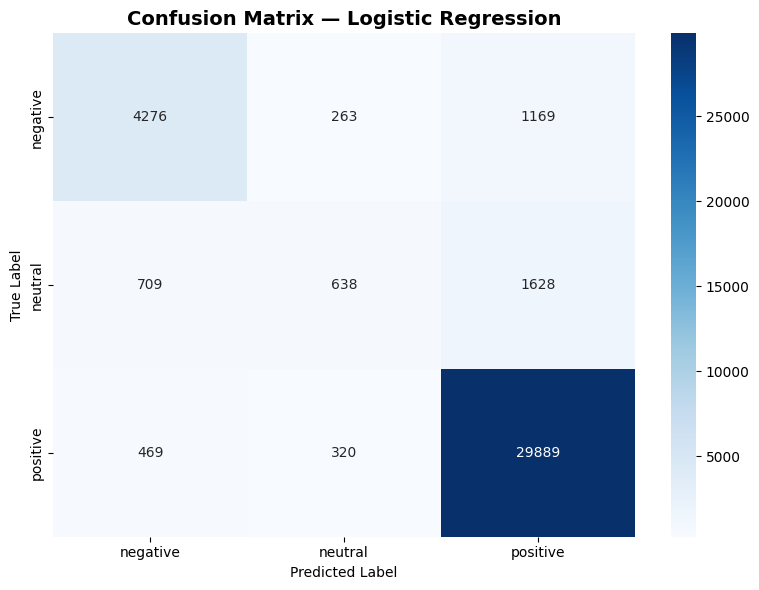

In [20]:
# ============================================================
# MODEL 1: Logistic Regression
# ============================================================
print('🚀 Training Logistic Regression...')

lr = LogisticRegression(
    max_iter=1000,
    C=1.0,
    solver='lbfgs',
    multi_class='multinomial',
    random_state=RANDOM_STATE
)
lr.fit(X_train_tfidf, y_train)

lr_results, lr_preds = evaluate_model(
    'Logistic Regression', lr,
    X_val_tfidf, y_val, X_test_tfidf, y_test, LABEL_NAMES
)
plot_confusion_matrix(y_test, lr_preds, 'Logistic Regression', LABEL_NAMES)
all_results.append(('Logistic Regression', lr, lr_results))

🚀 Training Naive Bayes...

  Naive Bayes
  Val  Accuracy:  0.8539
  Test Accuracy:  0.8574
  Test Precision: 0.8320
  Test Recall:    0.8574
  Test F1-Score:  0.8298

              precision    recall  f1-score   support

    negative       0.79      0.58      0.67      5708
     neutral       0.50      0.10      0.17      2975
    positive       0.87      0.98      0.92     30678

    accuracy                           0.86     39361
   macro avg       0.72      0.56      0.59     39361
weighted avg       0.83      0.86      0.83     39361



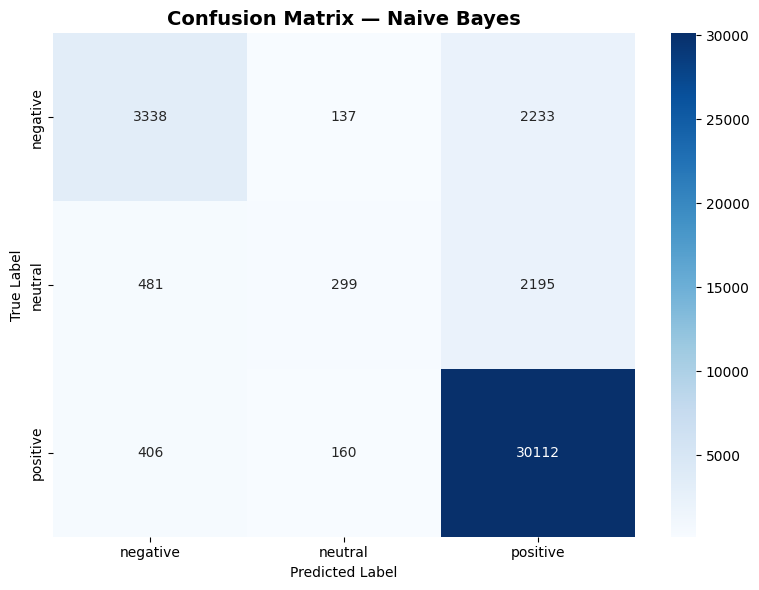

In [21]:
# ============================================================
# MODEL 2: Naive Bayes (Multinomial)
# ============================================================
print('🚀 Training Naive Bayes...')

nb = MultinomialNB(alpha=0.1)
nb.fit(X_train_tfidf, y_train)

nb_results, nb_preds = evaluate_model(
    'Naive Bayes', nb,
    X_val_tfidf, y_val, X_test_tfidf, y_test, LABEL_NAMES
)
plot_confusion_matrix(y_test, nb_preds, 'Naive Bayes', LABEL_NAMES)
all_results.append(('Naive Bayes', nb, nb_results))

🚀 Training Linear SVM...

  Linear SVM
  Val  Accuracy:  0.8772
  Test Accuracy:  0.8795
  Test Precision: 0.8612
  Test Recall:    0.8795
  Test F1-Score:  0.8666

              precision    recall  f1-score   support

    negative       0.76      0.75      0.75      5708
     neutral       0.47      0.22      0.30      2975
    positive       0.92      0.97      0.94     30678

    accuracy                           0.88     39361
   macro avg       0.72      0.65      0.67     39361
weighted avg       0.86      0.88      0.87     39361



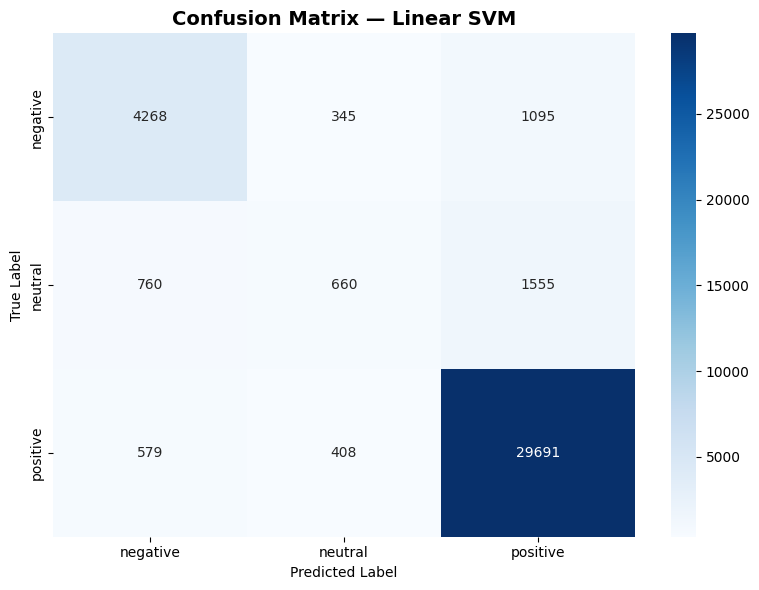

In [22]:
# ============================================================
# MODEL 3: Linear SVM
# ============================================================
print('🚀 Training Linear SVM...')

svm = LinearSVC(
    C=1.0,
    max_iter=2000,
    random_state=RANDOM_STATE
)
svm.fit(X_train_tfidf, y_train)

svm_results, svm_preds = evaluate_model(
    'Linear SVM', svm,
    X_val_tfidf, y_val, X_test_tfidf, y_test, LABEL_NAMES
)
plot_confusion_matrix(y_test, svm_preds, 'Linear SVM', LABEL_NAMES)
all_results.append(('Linear SVM', svm, svm_results))

🚀 Training Random Forest (may take a few minutes)...

  Random Forest
  Val  Accuracy:  0.7796
  Test Accuracy:  0.7797
  Test Precision: 0.7527
  Test Recall:    0.7797
  Test F1-Score:  0.6836

              precision    recall  f1-score   support

    negative       1.00      0.00      0.00      5708
     neutral       0.00      0.00      0.00      2975
    positive       0.78      1.00      0.88     30678

    accuracy                           0.78     39361
   macro avg       0.59      0.33      0.29     39361
weighted avg       0.75      0.78      0.68     39361



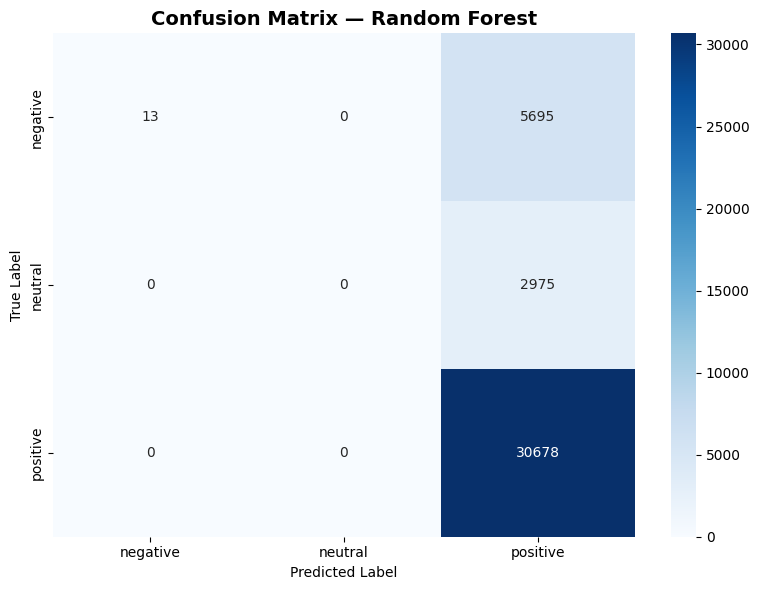

In [23]:
# ============================================================
# MODEL 4: Random Forest (with subset for speed)
# ============================================================
print('🚀 Training Random Forest (may take a few minutes)...')

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf.fit(X_train_tfidf, y_train)

rf_results, rf_preds = evaluate_model(
    'Random Forest', rf,
    X_val_tfidf, y_val, X_test_tfidf, y_test, LABEL_NAMES
)
plot_confusion_matrix(y_test, rf_preds, 'Random Forest', LABEL_NAMES)
all_results.append(('Random Forest', rf, rf_results))

## 7. Hyperparameter Tuning (Best Model)

In [24]:
# ============================================================
# Compare all models & select best by test F1
# ============================================================
comparison_df = pd.DataFrame([
    {
        'Model': name,
        'Val Accuracy':  res['val_accuracy'],
        'Test Accuracy': res['test_accuracy'],
        'Precision':     res['test_precision'],
        'Recall':        res['test_recall'],
        'F1-Score':      res['test_f1']
    }
    for name, _, res in all_results
]).sort_values('F1-Score', ascending=False)

print('\n=== Model Comparison ===')
print(comparison_df.to_string(index=False))

# Identify best model
best_name = comparison_df.iloc[0]['Model']
best_model = next(m for n, m, _ in all_results if n == best_name)
print(f'\n🏆 Best model: {best_name} (F1={comparison_df.iloc[0]["F1-Score"]:.4f})')


=== Model Comparison ===
              Model  Val Accuracy  Test Accuracy  Precision   Recall  F1-Score
Logistic Regression      0.881377       0.884200   0.865894 0.884200  0.869384
         Linear SVM      0.877185       0.879525   0.861227 0.879525  0.866556
        Naive Bayes      0.853913       0.857422   0.831972 0.857422  0.829842
      Random Forest      0.779649       0.779731   0.752683 0.779731  0.683561

🏆 Best model: Logistic Regression (F1=0.8694)


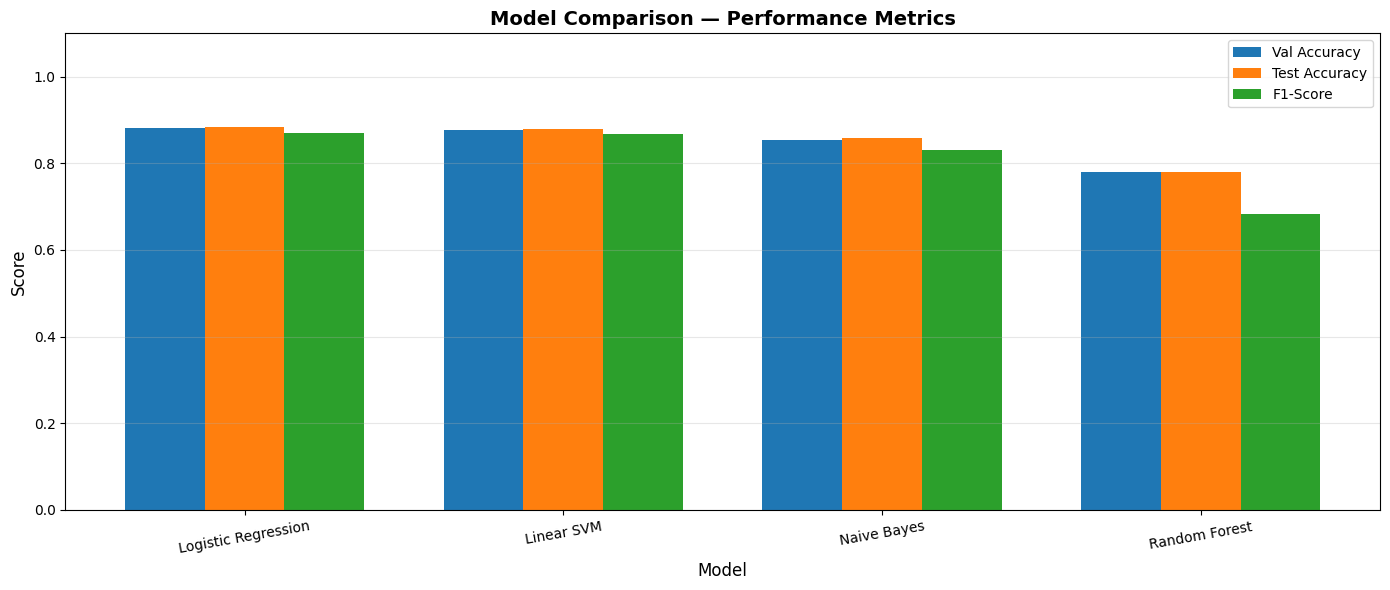

✅ Comparison chart saved


In [25]:
# Comparison Bar Chart
metrics = ['Val Accuracy', 'Test Accuracy', 'F1-Score']
x = np.arange(len(comparison_df))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 6))

for i, metric in enumerate(metrics):
    bars = ax.bar(x + i * width, comparison_df[metric], width, label=metric)

ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Comparison — Performance Metrics', fontsize=14, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(comparison_df['Model'], rotation=10)
ax.legend()
ax.set_ylim(0, 1.1)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('logs/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Comparison chart saved')

In [26]:
# ============================================================
# Hyperparameter Tuning for Logistic Regression (typically best for text)
# ============================================================
print('🔧 Hyperparameter tuning with GridSearchCV on Logistic Regression...')

param_grid = {
    'C': [0.1, 1.0, 10.0],
    'solver': ['lbfgs', 'saga'],
    'max_iter': [500, 1000]
}

grid_search = GridSearchCV(
    LogisticRegression(multi_class='multinomial', random_state=RANDOM_STATE),
    param_grid,
    cv=3,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train_tfidf, y_train)

print(f'\n✅ Best params: {grid_search.best_params_}')
print(f'   Best CV F1: {grid_search.best_score_:.4f}')

tuned_lr = grid_search.best_estimator_
tuned_results, tuned_preds = evaluate_model(
    'Tuned Logistic Regression', tuned_lr,
    X_val_tfidf, y_val, X_test_tfidf, y_test, LABEL_NAMES
)

🔧 Hyperparameter tuning with GridSearchCV on Logistic Regression...
Fitting 3 folds for each of 12 candidates, totalling 36 fits

✅ Best params: {'C': 1.0, 'max_iter': 500, 'solver': 'lbfgs'}
   Best CV F1: 0.8643

  Tuned Logistic Regression
  Val  Accuracy:  0.8814
  Test Accuracy:  0.8842
  Test Precision: 0.8659
  Test Recall:    0.8842
  Test F1-Score:  0.8694

              precision    recall  f1-score   support

    negative       0.78      0.75      0.77      5708
     neutral       0.52      0.21      0.30      2975
    positive       0.91      0.97      0.94     30678

    accuracy                           0.88     39361
   macro avg       0.74      0.65      0.67     39361
weighted avg       0.87      0.88      0.87     39361



## 8. Save Best Model

In [27]:
# Final best model selection (after tuning)
final_model = tuned_lr  # Update if another model is better
final_model_name = 'Logistic Regression (Tuned)'

# Save with joblib (primary)
joblib.dump(final_model, 'model/best_model.pkl')
print('✅ Model saved: model/best_model.pkl (joblib)')

# Save with pickle (backup)
with open('model/best_model_pickle.pkl', 'wb') as f:
    pickle.dump(final_model, f)
print('✅ Model saved: model/best_model_pickle.pkl (pickle)')

# Save model metadata
metadata = {
    'model_name': final_model_name,
    'test_accuracy': tuned_results['test_accuracy'],
    'test_f1': tuned_results['test_f1'],
    'test_precision': tuned_results['test_precision'],
    'test_recall': tuned_results['test_recall'],
    'classes': list(le.classes_),
    'label_map': {str(i): cls for i, cls in enumerate(le.classes_)},
    'tfidf_params': {
        'max_features': 50000,
        'ngram_range': [1, 2],
        'min_df': 2,
        'max_df': 0.95,
        'sublinear_tf': True
    }
}

with open('model/model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print('✅ Metadata saved: model/model_metadata.json')
print(f'\n🎉 Training complete! Best model: {final_model_name}')
print(f'   Test Accuracy: {tuned_results["test_accuracy"]:.4f}')
print(f'   Test F1-Score: {tuned_results["test_f1"]:.4f}')

✅ Model saved: model/best_model.pkl (joblib)
✅ Model saved: model/best_model_pickle.pkl (pickle)
✅ Metadata saved: model/model_metadata.json

🎉 Training complete! Best model: Logistic Regression (Tuned)
   Test Accuracy: 0.8842
   Test F1-Score: 0.8694


## Summary

| Artifact | Path |
|---|---|
| Best Model | `model/best_model.pkl` |
| TF-IDF Vectorizer | `model/tfidf_vectorizer.pkl` |
| Label Encoder | `model/label_encoder.pkl` |
| Metadata | `model/model_metadata.json` |
| Test Data | `data/test_reviews.csv` |

In [28]:
ls


kaggle.json  logs/  Mini-Projet/  model/  sample_data/


In [29]:
cp model/ Mini-Projet/

cp: -r not specified; omitting directory 'model/'


In [30]:
ls Mini-Projet/

database.sqlite  hashes.txt  Reviews.csv  test_reviews.csv


In [31]:
ls model/

best_model_pickle.pkl  label_encoder.pkl    tfidf_vectorizer.pkl
best_model.pkl         model_metadata.json


In [32]:
ls logs/

cm_linear_svm.png           cm_random_forest.png    wordcloud.png
cm_logistic_regression.png  model_comparison.png
cm_naive_bayes.png          score_distribution.png


In [34]:
from google.colab import files
import zipfile
import os

# Folders to include
folders = ["logs", "Mini-Projet", "model"]

# Name of zip file
zip_name = "project_folders1.zip"

# Create zip
with zipfile.ZipFile(zip_name, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for folder in folders:
        for root, dirs, files_in_dir in os.walk(folder):
            for file in files_in_dir:
                file_path = os.path.join(root, file)
                zipf.write(file_path)

print(f"{zip_name} created successfully!")

# Download zip
files.download(zip_name)

project_folders1.zip created successfully!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>